# This notebook shows how to compute the quantum geometric tensor (quantum metric and Berry curvature) of monolayer h-BN along $\Gamma$-K-M-K'-$\Gamma$
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### Ground state, and the occupied band window
Same h-BN slab as `05_berry_curvature.ipynb`: in-plane lattice constant of `vendor/elk/examples/piezoelectric/hBN`, B and N coplanar, vacuum along the 3rd lattice vector.

In [2]:
A, VACUUM = 4.743210000, 20.0  # Bohr
HBN_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
HBN_SPECIES = {"B": [(1 / 3, 2 / 3, 0.5)], "N": [(2 / 3, 1 / 3, 0.5)]}

hbn = Structure(HBN_AVEC, HBN_SPECIES).get_calculation("_scratch/hbn_quantum_geometry", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0)
hbn.get_energy()

first_block = (hbn.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist0, ist1 = 1, sum(o > 1.0 for o in occ)  # occupied count from EIGVAL.OUT, not an assumed electron count

### The quantum geometric tensor
$$ Q_{ab}(\mathbf k) = g_{ab}(\mathbf k) - \tfrac{i}{2}F_{ab}(\mathbf k), \qquad g_{ab}=\mathrm{Re}\,Q_{ab},\ \ F_{ab}=-2\,\mathrm{Im}\,Q_{ab} $$
$F_{ab}$ is the familiar Berry curvature of `05_berry_curvature.ipynb`. $g_{ab}$, the *quantum metric*, is the geometric information curvature alone misses: how far the occupied-band projector itself rotates in Hilbert space between $\mathbf k$ and $\mathbf k+d\mathbf k$, computed here from the same nearest-neighbour wavefunction overlaps as the Wilson loop, via `EigenstateSession.overlap()` queries -- no new Fortran task, unlike `get_berry_curvature_path()`.

In [3]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

G, K, M = (0, 0, 0), (1 / 3, 1 / 3, 0), (0.5, 0, 0)
# K' as the periodic image (2/3, -1/3, 0) rather than the more familiar
# (-1/3, -1/3, 0) -- same physical point (differs by the reciprocal lattice
# vector b1), but this image sits adjacent to M, so the path below hugs the
# BZ boundary the whole way instead of cutting through the interior near Gamma
Kp = (2 / 3, -1 / 3, 0)
segments = [segment(G, K, 7)] + [segment(a, b, 7)[1:] for a, b in [(K, M), (M, Kp), (Kp, G)]]
# index of the LAST point of each segment (G, K, M, K', G) in the concatenated path
ticks = np.concatenate([[0], np.cumsum([len(s) for s in segments]) - 1])
path = sum(segments, [])

result = hbn.get_quantum_geometry(path, ist0, ist1, directions=(1, 2), dk=0.01, label="qg_path_GKMKpG")
g11 = np.array([r["g"][0, 0] for r in result])
g22 = np.array([r["g"][1, 1] for r in result])
omega = np.array([r["berry_curvature"] for r in result])

### Time-reversal symmetry: $g_{ab}(-\mathbf k)=g_{ab}(\mathbf k)$, but $\Omega(-\mathbf k)=-\Omega(\mathbf k)$
Broken B/N sublattice inversion symmetry makes K and $K'=-K$ physically inequivalent valleys, but they remain time-reversal partners: the metric at the two valleys must agree, while the curvature must flip sign -- unlike `05_berry_curvature.ipynb`'s $\Omega(K')=-\Omega(K)$ alone, this is a genuinely new prediction about $g_{ab}$, not derivable from curvature.

In [4]:
iK, iM, iKp = ticks[1], ticks[2], ticks[3]
print("g11(K), g11(K'):", g11[iK], g11[iKp])
print("Omega(K), Omega(K'):", omega[iK], omega[iKp])

g11(K), g11(K'): 6.238639356407222 6.2386393564043745
Omega(K), Omega(K'): -8.086262995482262 8.081900185793726


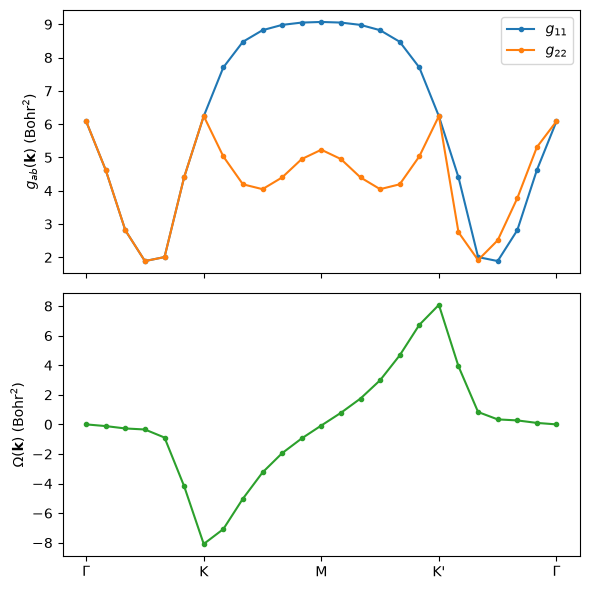

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
ax1.plot(g11, marker="o", ms=3, label=r"$g_{11}$")
ax1.plot(g22, marker="o", ms=3, label=r"$g_{22}$")
ax1.set_ylabel(r"$g_{ab}(\mathbf{k})$ (Bohr$^2$)")
ax1.legend()
ax2.plot(omega, marker="o", ms=3, color="C2")
ax2.set_ylabel(r"$\Omega(\mathbf{k})$ (Bohr$^2$)")
ax2.set_xticks(ticks)
ax2.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
plt.tight_layout()
plt.show()

Note the cusp in $g_{11}$/$g_{22}$ exactly at K and K': the *individual* coordinate components $g_{ab}$ depend on the fixed (direction-1, direction-2) frame the loop is built from, while only rotation-invariant combinations (e.g. the eigenvalues of $g$, or $\det g$) need to vary smoothly through a 3-fold-symmetric point like K, where the metric's own principal axes need not stay aligned with that fixed frame on both sides.